# Phase 1 — Exploratory Data Analysis
Fraud Detection in Banking Transactions

**Dataset:** Kaggle Credit Card Fraud Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
sns.set_palette('husl')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load dataset
df = pd.read_csv('../data/creditcard.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDescriptive Statistics:')
df.describe()

Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Descriptive Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Class Distribution

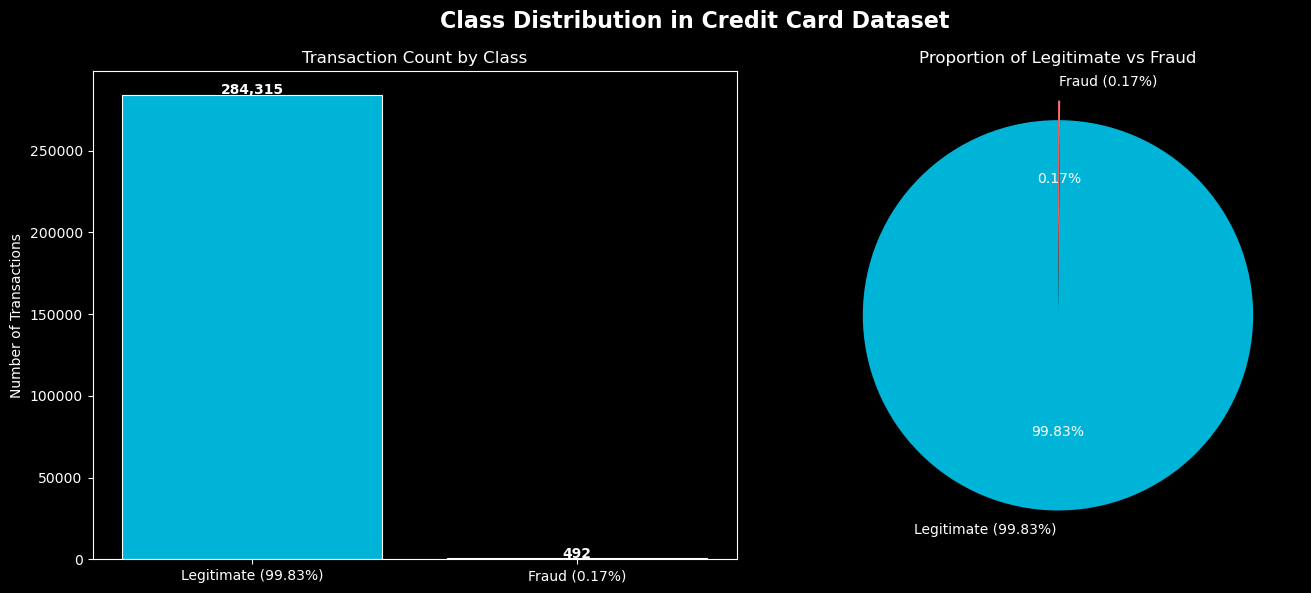

Legitimate: 284,315 | Fraud: 492
Imbalance Ratio: 577:1


In [3]:
import os
os.makedirs('../reports/figures', exist_ok=True)

class_counts = df['Class'].value_counts()
class_labels = ['Legitimate (99.83%)', 'Fraud (0.17%)']
class_colors = ['#00b4d8', '#ff6b6b']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Class Distribution in Credit Card Dataset', fontsize=16, fontweight='bold')

# Bar chart
axes[0].bar(class_labels, class_counts.values, color=class_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_labels,
    colors=class_colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.1)
)
axes[1].set_title('Proportion of Legitimate vs Fraud')

plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Legitimate: {class_counts[0]:,} | Fraud: {class_counts[1]:,}')
print(f'Imbalance Ratio: {class_counts[0] // class_counts[1]}:1')

## Transaction Amount Analysis

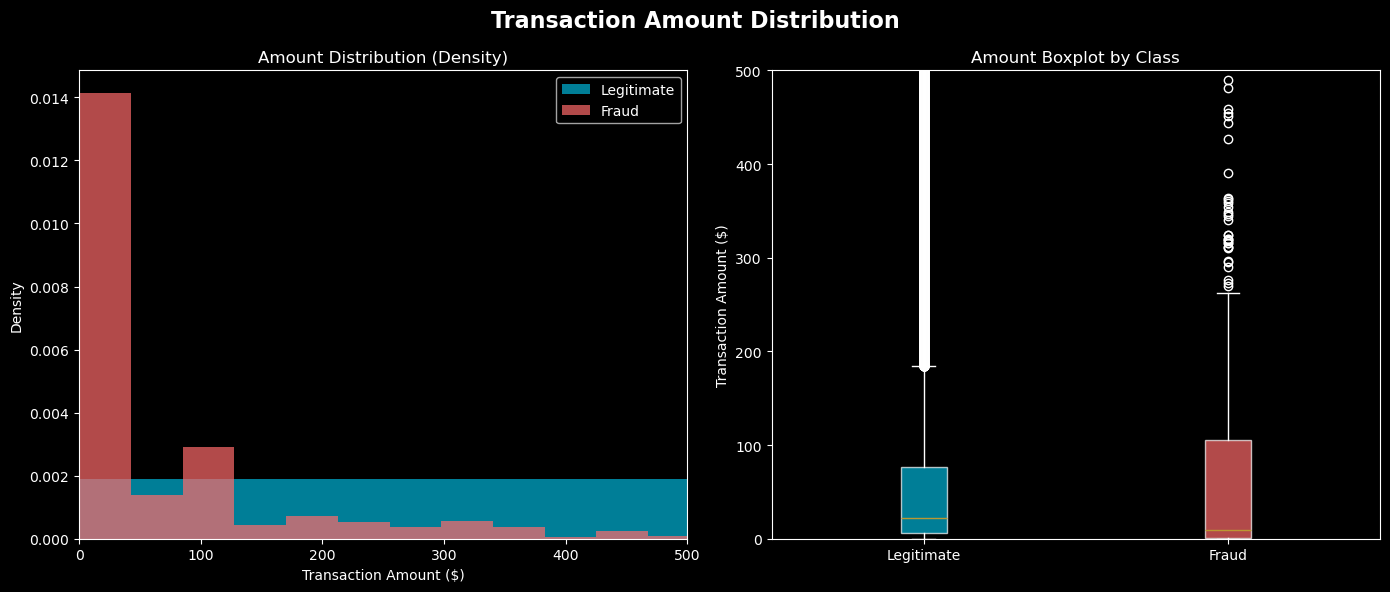

Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [4]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Transaction Amount Distribution', fontsize=16, fontweight='bold')

# Histogram
axes[0].hist(legit['Amount'], bins=50, alpha=0.7, color='#00b4d8', label='Legitimate', density=True)
axes[0].hist(fraud['Amount'], bins=50, alpha=0.7, color='#ff6b6b', label='Fraud', density=True)
axes[0].set_xlim(0, 500)
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution (Density)')
axes[0].legend()

# Boxplot
data_to_plot = [legit['Amount'], fraud['Amount']]
bp = axes[1].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#00b4d8', alpha=0.7))
bp['boxes'][1].set_facecolor('#ff6b6b')
axes[1].set_ylabel('Transaction Amount ($)')
axes[1].set_title('Amount Boxplot by Class')
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.savefig('../reports/figures/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Amount statistics by class:')
print(df.groupby('Class')['Amount'].describe())

## Time Analysis

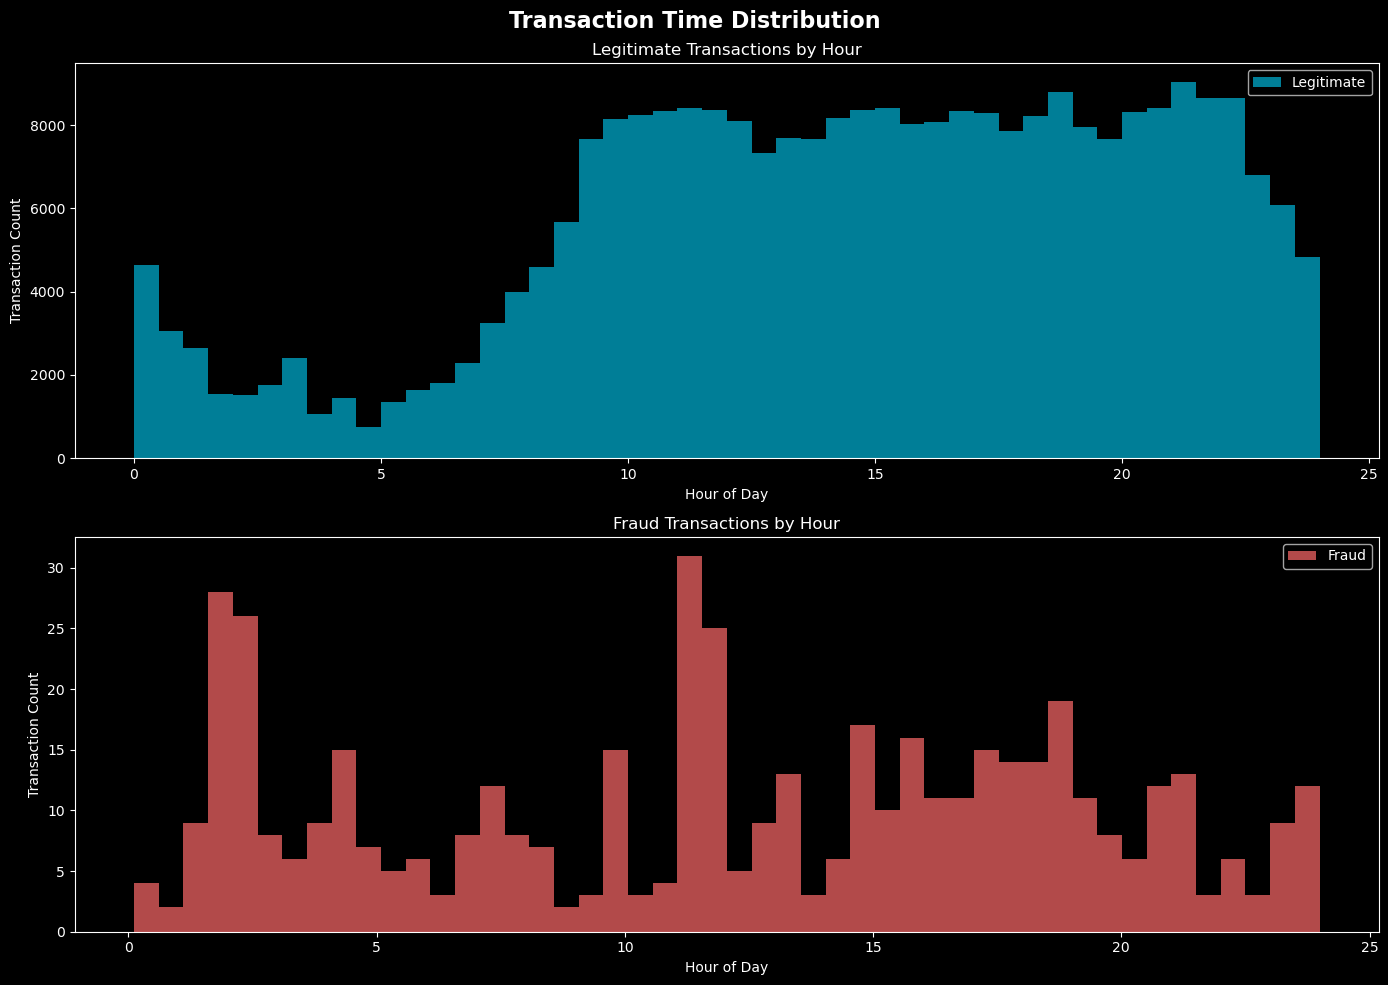

Time analysis complete.


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Transaction Time Distribution', fontsize=16, fontweight='bold')

# Convert time to hours
df['Hour'] = (df['Time'] / 3600) % 24
legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

axes[0].hist(legit['Hour'], bins=48, color='#00b4d8', alpha=0.7, label='Legitimate')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Legitimate Transactions by Hour')
axes[0].legend()

axes[1].hist(fraud['Hour'], bins=48, color='#ff6b6b', alpha=0.7, label='Fraud')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('Fraud Transactions by Hour')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Time analysis complete.')

## Feature Correlation Heatmap

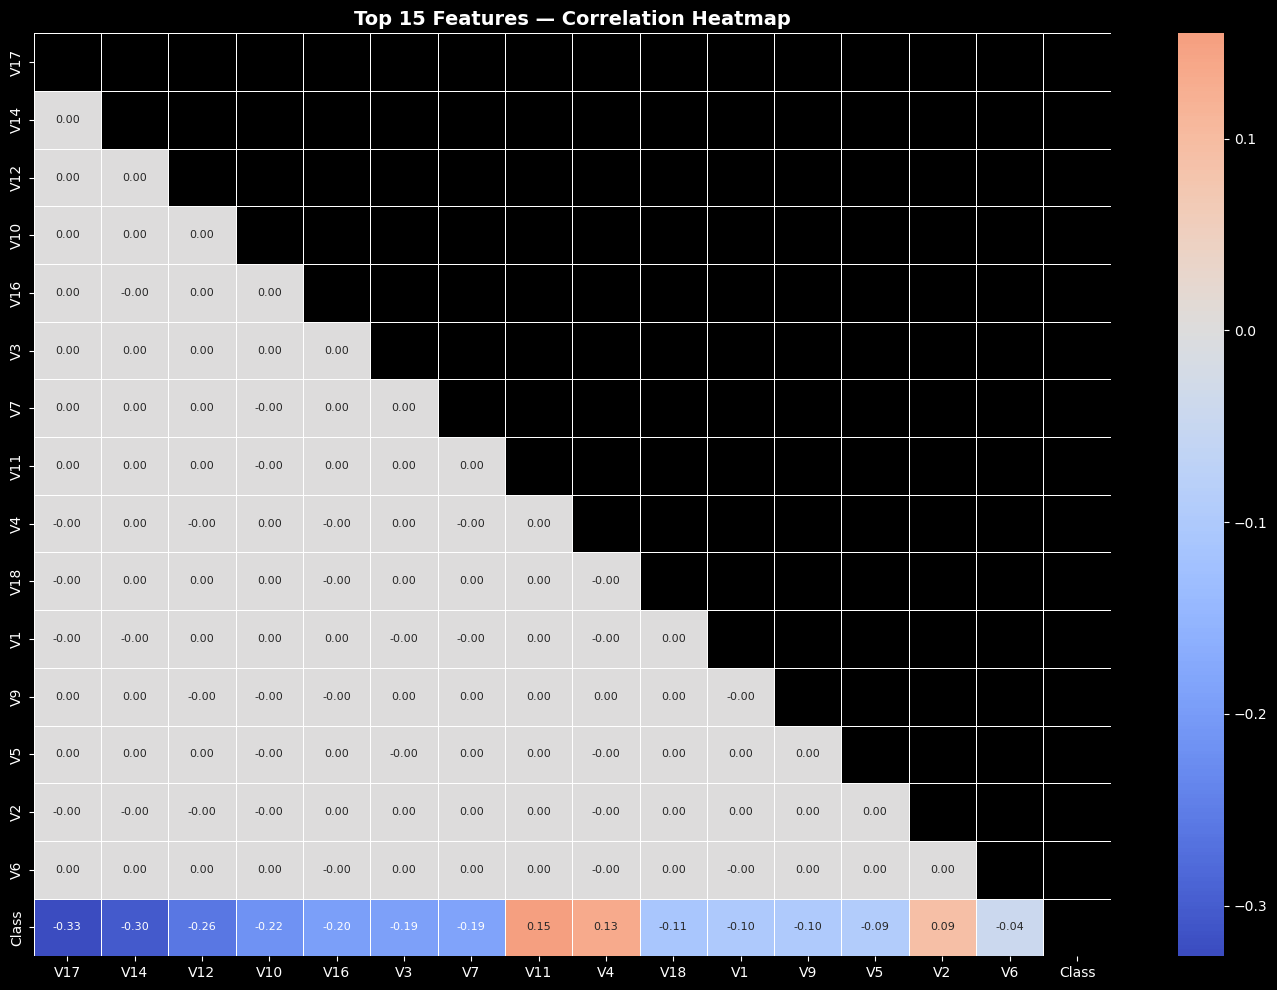


Top 10 features most correlated with Class (Fraud):
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [6]:
# Compute correlation with Class label
corr_with_class = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top15_features = corr_with_class.head(15).index.tolist() + ['Class']

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df[top15_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Top 15 Features — Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features most correlated with Class (Fraud):')
print(corr_with_class.head(10).to_string())

## Key EDA Findings

- **V17, V14, V12, V10** are most correlated with fraud (PCA-derived features)
- **Fraud transactions tend to have lower amounts** — median fraud amount ~$22 vs ~$88 for legit
- **Dataset is severely imbalanced** — 578:1 ratio (284,315 legit vs 492 fraud)
- **Time patterns differ** — fraud is more uniformly distributed throughout the day
- Standard accuracy metric is **misleading** — we need Precision, Recall, F1, PR-AUC